In [1]:
!mamba install pandas numpy matplotlib seaborn scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, seaborn, scikit-learn
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 3.31140000000014 seconds
  Name                          Version                       Build                         Channel                       
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
+ brotli-python                 1.2.0                         py313h33caa6c_0               emscripten-forge              
+ certifi                       2026.4.22                     pyhd8ed1ab_0                  conda-forge                   
+ charset-normalizer            3.4.7                         pyhd8ed1ab_0                  conda-forge                   
+ idna                          3.13                          pyhcf101f3_0                  conda-forge                   
+ joblib                      

In [2]:
# Loading data and taking an initial view of the data frame.
df = pd.read_csv('NYPD_Arrest_Data_(Year_to_Date)_20260506 (1).csv')
df.head()

,ARREST_KEY,ARREST_DATE,PD_CD,PD_DESC,KY_CD,OFNS_DESC,LAW_CODE,LAW_CAT_CD,ARREST_BORO,ARREST_PRECINCT,JURISDICTION_CODE,AGE_GROUP,PERP_SEX,PERP_RACE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Location
0,318451126,01/06/2026,105.0,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,Q,110,0,25-44,M,BLACK,1020232,210719,40.744989,-73.870145,POINT (-73.870145 40.744989)
1,318308486,01/03/2026,203.0,"TRESPASS 3, CRIMINAL",352.0,CRIMINAL TRESPASS,PL 140100G,M,K,77,1,25-44,M,BLACK,1003358,182945,40.668798,-73.931120,POINT (-73.93112014 40.66879784)
2,318550123,01/08/2026,105.0,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,B,48,0,25-44,M,WHITE HISPANIC,1011780,246837,40.844152,-73.900500,POINT (-73.9005 40.844152)
3,318580867,01/07/2026,397.0,"ROBBERY,OPEN AREA UNCLASSIFIED",105.0,ROBBERY,PL 160102B,F,M,28,0,(null),(null),BLACK,999788,233328,40.807102,-73.943874,POINT (-73.943874 40.807102)
4,318684449,01/10/2026,397.0,"ROBBERY,OPEN AREA UNCLASSIFIED",105.0,ROBBERY,PL 160102A,F,B,45,0,<18,F,BLACK,1031351,254245,40.864401,-73.829711,POINT (-73.829711 40.864401)


In [16]:
#Data Cleaning for the areas that I want to compare [by Borough (Brooklyn {K} & Queens {Q}) then by Level of offense: misdemeanor as this is what I want to concentrate and then finaly by gender. 
new_df = df[df['ARREST_BORO'].isin(['Q', 'K'])]
new_df = new_df[new_df['LAW_CAT_CD'].isin(['M'])]
new_df = new_df[new_df['PERP_SEX'].isin(['M', 'F'])]

In [17]:
#This is the descriptive statistic
stats = new_df.groupby(['ARREST_BORO', 'PERP_SEX'])['LAW_CAT_CD'].count()
print(stats)

ARREST_BORO  PERP_SEX
K            F           1695
             M           7286
Q            F           1476
             M           5611
Name: LAW_CAT_CD, dtype: int64


<module 'matplotlib.pyplot' from '/lib/python3.13/site-packages/matplotlib/pyplot.py'>

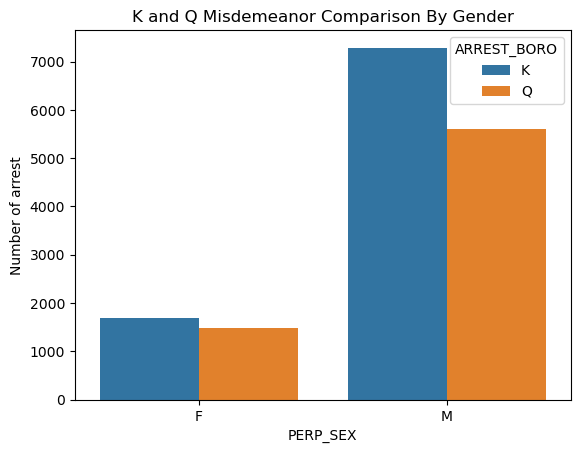

In [21]:
# Data Visualization
sns.barplot(x=stats.index.get_level_values(1), y=stats.values, hue=stats.index.get_level_values(0))
plt.title('K and Q Misdemeanor Comparison By Gender')
plt.xlabel('PERP_SEX')
plt.ylabel('Number of arrest')
plt

In [ ]:
#Conclusion: Based on the data provided we can conclude that Brooklyn has more misdemeanor arrest than Queens overall. When looking at the data by gender there is not much difference between females by Borough, however we it came to males we can notice a higher number of arrests in Brooklyn compared to Queens. In both cases the males misdemeanors are significative higher than females. 